# 04. 워크플로 패턴 — 5가지 핵심 패턴

## 학습 목표

Prompt Chaining, Parallelization, Routing, Orchestrator-Worker, Evaluator-Optimizer 패턴을 이해합니다.

## 4.1 환경 설정

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-5.4")

In [2]:
# Observability 설정 (선택) - LangSmith 또는 Langfuse
# .env에 키를 설정하거나, 아래 주석을 해제하여 직접 입력하세요.
# os.environ["LANGFUSE_SECRET_KEY"] = "sk-lf-..."
# os.environ["LANGFUSE_PUBLIC_KEY"] = "pk-lf-..."
# os.environ["LANGFUSE_HOST"] = "https://lf.ddok.ai"
import os

# LangSmith: LANGSMITH_TRACING=true 시 자동 활성화 (코드 수정 불필요)
if os.environ.get("LANGSMITH_TRACING", "").lower() == "true":
    os.environ.setdefault("LANGCHAIN_TRACING_V2", "true")
    os.environ.setdefault("LANGCHAIN_API_KEY", os.environ.get("LANGSMITH_API_KEY", ""))
    os.environ.setdefault("LANGCHAIN_PROJECT", os.environ.get("LANGSMITH_PROJECT", "default"))
    print(f"LangSmith tracing ON \u2014 project: {os.environ['LANGCHAIN_PROJECT']}")

# Langfuse: invoke/stream 호출 시 config={"callbacks": [langfuse_handler]} 전달
langfuse_handler = None
if os.environ.get("LANGFUSE_SECRET_KEY"):
    from langfuse.langchain import CallbackHandler
    langfuse_handler = CallbackHandler()
    print(f"Langfuse tracing ON \u2014 {os.environ.get('LANGFUSE_HOST', '')}")

# Langfuse config: pass to invoke/stream/batch calls
lf_config = {"callbacks": [langfuse_handler]} if langfuse_handler else {}


LangSmith tracing ON — project: day1-labs-test


## 4.2 Prompt Chaining — 순차적 LLM 호출

- 각 단계의 출력이 다음 단계의 입력이 됨
- 용도: 번역 → 검증 → 교정, 분석 → 요약 → 포맷팅

![Prompt Chaining](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/prompt_chain.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=762dec147c31b8dc6ebb0857e236fc1f)

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class ChainState(TypedDict):
    topic: str
    draft: str
    improved: str

def generate_draft(state: ChainState) -> dict:
    response = model.invoke(f"다음에 대한 한 문장 사실을 작성해주세요: {state['topic']}", config=lf_config)
    return {"draft": response.content}

def improve_draft(state: ChainState) -> dict:
    response = model.invoke(f"다음 텍스트를 더 매력적으로 개선해주세요: {state['draft']}", config=lf_config)
    return {"improved": response.content}

builder = StateGraph(ChainState)
builder.add_node("draft", generate_draft)
builder.add_node("improve", improve_draft)
builder.add_edge(START, "draft")
builder.add_edge("draft", "improve")
builder.add_edge("improve", END)

chain = builder.compile()
result = chain.invoke({"topic": "Python 프로그래밍"}, config=lf_config)
print(f"초안: {result['draft']}")
print(f"개선: {result['improved']}")

초안: 파이썬(Python)은 읽기 쉬운 문법과 다양한 라이브러리를 갖춘 범용 프로그래밍 언어입니다.
개선: 물론입니다. 더 매력적으로 다듬은 버전은 다음과 같습니다:

**파이썬(Python)은 간결하고 읽기 쉬운 문법, 그리고 풍부한 라이브러리를 바탕으로 웹 개발, 데이터 분석, 인공지능 등 다양한 분야에서 폭넓게 활용되는 강력한 범용 프로그래밍 언어입니다.**

원하시면 제가 이 문장을  
- **더 전문적으로**
- **더 짧고 임팩트 있게**
- **홍보문구처럼**
- **초보자 친화적으로**  
다양한 스타일로도 바꿔드릴 수 있습니다.


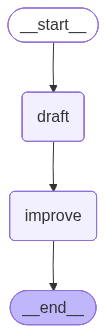

In [4]:
from IPython.display import Image, display

display(Image(chain.get_graph().draw_mermaid_png()))

## 4.3 Parallelization — 독립적 태스크의 동시 실행

![Parallelization](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/parallelization.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=8afe3c427d8cede6fed1e4b2a5107b71)

In [5]:
from typing import Annotated, TypedDict
import operator


class ParallelState(TypedDict):
    text: str
    analyses: Annotated[list[str], operator.add] #리듀서 등장


def analyze_tone(state: ParallelState) -> dict:
    r = model.invoke(
        f"한 문장으로 다음의 어조를 설명해주세요: {state['text']}",
        config=lf_config
    )
    return {
        "analyses": [f"어조: {r.content}"]
    }


def analyze_complexity(state: ParallelState) -> dict:
    r = model.invoke(
        f"한 문장으로 다음의 복잡도를 평가해주세요: {state['text']}",
        config=lf_config
    )
    return {
        "analyses": [f"복잡도: {r.content}"]
    }


def synthesize(state: ParallelState) -> dict:
    return {
        "analyses": [
            f"종합: {len(state['analyses'])}개 분석 완료"
        ]
    }


builder = StateGraph(ParallelState)

builder.add_node("tone", analyze_tone)
builder.add_node("complexity", analyze_complexity)
builder.add_node("synthesize", synthesize)

# START에서 두 분석 노드로 병렬 분기
builder.add_edge(START, "tone")
builder.add_edge(START, "complexity")

# 두 노드 완료 후 합성
builder.add_edge("tone", "synthesize")
builder.add_edge("complexity", "synthesize")
builder.add_edge("synthesize", END)

parallel_graph = builder.compile()

result = parallel_graph.invoke(
    {
        "text": "LangGraph는 강력한 에이전트 워크플로를 가능하게 합니다.",
        "analyses": []
    },
    config=lf_config
)

for a in result["analyses"]:
    print(f"  {a}")

  복잡도: 이 문장은 개념적으로는 쉬운 편이지만, “에이전트 워크플로”와 “LangGraph” 같은 전문 용어 때문에 전반적 복잡도는 **중간 수준**입니다.
  어조: 차분하고 전문적인 어조로, 기술의 역량을 자신감 있게 강조하는 설명적 문장입니다.
  종합: 2개 분석 완료


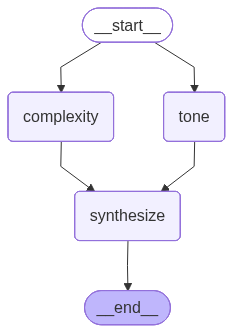

In [6]:
display(Image(parallel_graph.get_graph().draw_mermaid_png()))

## 4.4 Routing — 분류 기반 분기

![Routing](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/routing.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=272e0e9b681b89cd7d35d5c812c50ee6)

In [7]:
from pydantic import BaseModel, Field
from typing import Literal, TypedDict


class Classification(BaseModel):
    category: Literal["technical", "business", "casual"] #무조건 하나만 뱉도록
#literal: 정확히 문자열 이 값들 중 하나라는 말

class RouteState(TypedDict):
    question: str
    category: str
    answer: str


def classify(state: RouteState) -> dict:
    structured = model.with_structured_output(Classification)
    result = structured.invoke(
        f"다음 질문을 분류하세요: {state['question']}",
        config=lf_config
    )
    return {"category": result.category}


def handle_technical(state: RouteState) -> dict:
    r = model.invoke(
        f"기술 전문가로서 답변해주세요: {state['question']}",
        config=lf_config
    )
    return {"answer": r.content}


def handle_business(state: RouteState) -> dict:
    r = model.invoke(
        f"비즈니스 어드바이저로서 답변해주세요: {state['question']}",
        config=lf_config
    )
    return {"answer": r.content}


def handle_casual(state: RouteState) -> dict:
    r = model.invoke(
        f"가볍게 답변해주세요: {state['question']}",
        config=lf_config
    )
    return {"answer": r.content}


def route(state: RouteState) -> str:
    return state["category"]


builder = StateGraph(RouteState)

builder.add_node("classify", classify)
builder.add_node("technical", handle_technical)
builder.add_node("business", handle_business)
builder.add_node("casual", handle_casual)

builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route, {
    "technical": "technical",
    "business": "business",
    "casual": "casual",
})

builder.add_edge("technical", END)
builder.add_edge("business", END)
builder.add_edge("casual", END)

router = builder.compile()

result = router.invoke(
    {
        "question": "Python에서 가비지 컬렉션은 어떻게 작동하나요?"
    },
    config=lf_config
)

print(f"카테고리: {result['category']}")
print(f"답변: {result['answer'][:200]}")

카테고리: technical
답변: Python의 가비지 컬렉션은 주로 **참조 카운팅(reference counting)** 과 **순환 참조 감지(cyclic garbage collection)** 두 가지 방식으로 작동합니다.

## 1. 참조 카운팅
Python 객체는 자신을 참조하는 수를 추적합니다.

- 변수가 객체를 가리키면 참조 수가 증가
- 변수가 사라지거나 다른 객체를 가리


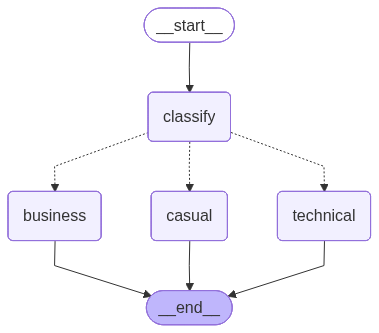

In [8]:
display(Image(router.get_graph().draw_mermaid_png()))

## 4.5 Orchestrator-Worker — Send()로 동적 워커 생성

![Orchestrator-Worker](https://mintcdn.com/langchain-5e9cc07a/ybiAaBfoBvFquMDz/oss/images/worker.png?fit=max&auto=format&n=ybiAaBfoBvFquMDz&q=85&s=2e423c67cd4f12e049cea9c169ff0676)

In [9]:
from langgraph.types import Send
from typing import Annotated, TypedDict
import operator


class OrchestratorState(TypedDict):
    topic: str
    sections: list[str]
    results: Annotated[list[str], operator.add]


class WorkerState(TypedDict):
    section: str


def plan_sections(state: OrchestratorState) -> dict:
    r = model.invoke(
        f"'{state['topic']}'에 대한 기사의 짧은 섹션 제목 3개를 나열해주세요. 한 줄에 하나씩, 번호 없이.",
        config=lf_config
    )

    sections = [
        s.strip()
        for s in r.content.strip().split("\n")
        if s.strip()
    ][:3]

    return {"sections": sections}


def assign_workers(state: OrchestratorState) -> list[Send]:
    return [
        Send("worker", {"section": s})
        for s in state["sections"]
    ]


def worker(state: WorkerState) -> dict:
    r = model.invoke(
        f"다음에 대해 한 문장으로 작성해주세요: {state['section']}",
        config=lf_config
    )

    return {
        "results": [
            f"## {state['section']}\n{r.content}"
        ]
    }


builder = StateGraph(OrchestratorState)

builder.add_node("plan", plan_sections)
builder.add_node("worker", worker)

builder.add_edge(START, "plan")

builder.add_conditional_edges(
    "plan",
    assign_workers,
    ["worker"]
)

builder.add_edge("worker", END)

orchestrator = builder.compile()

result = orchestrator.invoke(
    {
        "topic": "머신러닝",
        "sections": [],
        "results": []
    },
    config=lf_config
)

for r in result["results"]:
    print(r)
    print()

## 머신러닝의 기본 개념
머신러닝은 컴퓨터가 명시적인 규칙을 일일이 프로그래밍하지 않아도 데이터에서 패턴을 학습해 예측이나 판단을 수행하도록 하는 인공지능의 한 분야입니다.

## 실생활 속 머신러닝 활용
머신러닝은 추천 시스템, 음성 인식, 자율주행, 의료 진단 등 실생활의 다양한 분야에서 데이터를 분석해 더 편리하고 효율적인 서비스를 제공하는 데 활용됩니다.

## 머신러닝의 미래와 과제
머신러닝의 미래는 의료, 교육, 산업 전반의 혁신을 이끌 잠재력이 크지만, 동시에 데이터 편향, 개인정보 보호, 설명 가능성, 윤리적 책임과 같은 과제를 해결해야 지속 가능하게 발전할 수 있습니다.



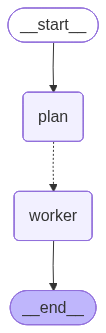

In [10]:
display(Image(orchestrator.get_graph().draw_mermaid_png()))

__start__ → plan ⇢ worker → __end__
plan ⇢ worker 점선 = 동적 분기. plan이 정한 섹션 수만큼 worker가 펼쳐집니다.

예시: topic = "머신러닝"
1) __start__ → plan

초기 State: {"topic": "머신러닝", "sections": [], "results": []}

2) plan 실행

LLM에게 "머신러닝 기사 섹션 제목 3개" 요청 → 결과를 줄 단위로 잘라 저장.


sections = [
  "머신러닝의 기본 개념",
  "실생활 속 머신러닝 활용",
  "머신러닝의 미래와 과제"
]
3) plan ⇢ worker (동적 분기)

assign_workers가 Send 3개 반환:


Send("worker", {"section": "머신러닝의 기본 개념"})
Send("worker", {"section": "실생활 속 머신러닝 활용"})
Send("worker", {"section": "머신러닝의 미래와 과제"})
→ worker 노드가 3개로 복제되어 동시 실행.

4) worker × 3 (병렬)

각 워커는 자기가 받은 섹션 제목으로 LLM에 한 문장 작성을 요청.


worker("기본 개념")  → results: ["## 머신러닝의 기본 개념\n데이터로 패턴을 학습..."]
worker("실생활 활용") → results: ["## 실생활 속 머신러닝 활용\n음성인식, 추천..."]
worker("미래와 과제") → results: ["## 머신러닝의 미래와 과제\n편향과 윤리..."]
reducer(operator.add)가 자동으로 합침:


results = [
  "## 머신러닝의 기본 개념\n...",
  "## 실생활 속 머신러닝 활용\n...",
  "## 머신러닝의 미래와 과제\n..."
]
5) worker → __end__

종료. 사용자는 한 편의 기사 초안(섹션 3개)을 받음.

핵심
그림상 worker는 박스 1개지만, 실행 시엔 plan이 만든 섹션 수만큼 복제됨
topic이 "양자컴퓨터"면 섹션 5개로, "고양이"면 2개로 — 그래프는 그대로
점선 = "런타임에 워커 개수가 정해진다"는 뜻

## 4.6 Evaluator-Optimizer — 생성-평가 반복 루프

![Evaluator-Optimizer](https://mintcdn.com/langchain-5e9cc07a/-_xGPoyjhyiDWTPJ/oss/images/evaluator_optimizer.png?fit=max&auto=format&n=-_xGPoyjhyiDWTPJ&q=85&s=9bd0474f42b6040b14ed6968a9ab4e3c)

In [11]:
class EvalState(TypedDict):
    task: str
    draft: str
    feedback: str
    is_good: bool
    iterations: int

def generate(state: EvalState) -> dict:
    if state.get("feedback"):
        prompt = f"피드백을 반영하여 개선해주세요.\n원본: {state['draft']}\n피드백: {state['feedback']}"
    else:
        prompt = f"다음에 대한 한 문장 슬로건을 작성해주세요: {state['task']}"
    r = model.invoke(prompt, config=lf_config)
    return {"draft": r.content, "iterations": state.get("iterations", 0) + 1}

def evaluate(state: EvalState) -> dict:
    r = model.invoke(f"이 슬로건을 1-10으로 평가하고 간단한 피드백을 주세요: '{state['draft']}'", config=lf_config)
    content = r.content
    is_good = any(f"{n}/10" in content for n in range(8, 11))
    return {"feedback": content, "is_good": is_good}

def should_retry(state: EvalState) -> str:
    if state["is_good"] or state["iterations"] >= 3:
        return END
    return "generate"

builder = StateGraph(EvalState)
builder.add_node("generate", generate)
builder.add_node("evaluate", evaluate)

builder.add_edge(START, "generate")
builder.add_edge("generate", "evaluate")
builder.add_conditional_edges("evaluate", should_retry, ["generate", END])

optimizer = builder.compile()
result = optimizer.invoke({"task": "Python 학습 플랫폼"}, config=lf_config)
print(f"최종 초안 ({result['iterations']}번 반복 후): {result['draft']}")

최종 초안 (1번 반복 후): 코드 한 줄의 성취가 실력으로 이어지는, 가장 쉬운 Python 학습 플랫폼.


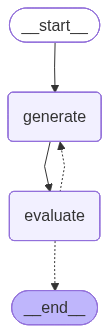

In [12]:
display(Image(optimizer.get_graph().draw_mermaid_png()))

## 4.7 패턴 비교표

| 패턴 | 결정적 | 병렬 | 반복 | 적합 상황 |
|------|--------|------|------|----------|
| Prompt Chaining | O | X | 순차 | 단계별 변환 |
| Parallelization | O | O | X | 독립 분석 |
| Routing | O | X | X | 분류 기반 처리 |
| Orchestrator-Worker | O | O | X | 동적 하위 작업 |
| Evaluator-Optimizer | X | X | O | 품질 개선 루프 |